# 04 — Train Transformer autoencoder & export to ONNX (local)

**Option C** from [`docs/model_architecture_options.md`](../docs/model_architecture_options.md):
a small Transformer encoder-decoder autoencoder trained on the clean
multivariate telemetry, evaluated against the labelled eval snapshot,
exported to ONNX.

This notebook is fully **local**: no Fabric / KQL dependency. Reads the
parquets generated by `notebooks/01_simulator_dev.ipynb`, writes
artifacts under `models/transformer_ae/`.

Pipeline:

1. Load training (`data/training/telemetry_wide.parquet`, clean) and
   eval (`data/eval/telemetry_wide.parquet` + `anomaly_labels.parquet`).
2. Drop OFF samples, per-sensor z-score (fit on training only),
   build sliding windows of `WINDOW = 64` samples with stride `STRIDE = 16`.
3. Train a Transformer encoder-decoder AE on GPU.
4. Score every eval window, aggregate per-row (max-reduction over
   overlapping windows), compute PR-AUC per fault family, detection
   delay, FP rate on healthy controls.
5. Export `ScoreWrapper(window) -> reconstruction_mse` to ONNX,
   round-trip with `onnxruntime` to confirm parity, persist the scaler
   and threshold alongside.

## 1. Config & imports

In [1]:
from __future__ import annotations

import json
import math
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 1337
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Paths
REPO_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_TRAIN = REPO_ROOT / "data" / "training" / "telemetry_wide.parquet"
DATA_EVAL  = REPO_ROOT / "data" / "eval"     / "telemetry_wide.parquet"
DATA_LBL   = REPO_ROOT / "data" / "eval"     / "anomaly_labels.parquet"
ART_DIR    = REPO_ROOT / "models" / "transformer_ae"
ART_DIR.mkdir(parents=True, exist_ok=True)

# Sensor order must stay stable across train / eval / ONNX export.
SENSORS = [
    "vibration_axial", "vibration_radial",
    "temperature_motor", "temperature_bearing",
    "pressure_hydraulic", "current", "power", "spindle_rpm",
]
N_FEATURES = len(SENSORS)

# Windowing
WINDOW = 64           # 64 s @ 1 Hz
STRIDE_TRAIN = 16     # 75% overlap during training
STRIDE_EVAL  = 1      # dense scoring at inference so detection_delay is meaningful

# Model (Option C — Transformer encoder-decoder)
D_MODEL  = 64
N_HEADS  = 4
N_ENC    = 2
N_DEC    = 2
FF_DIM   = 128
DROPOUT  = 0.1

# Training
BATCH    = 256
EPOCHS   = 12
LR       = 3e-4
WEIGHT_DECAY = 1e-5
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device           : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu              : {torch.cuda.get_device_name(0)}")
print(f"sensors          : {SENSORS}")
print(f"window / strides : W={WINDOW}, train_stride={STRIDE_TRAIN}, eval_stride={STRIDE_EVAL}")
print(f"artifact dir     : {ART_DIR.relative_to(REPO_ROOT)}")

device           : cuda
gpu              : NVIDIA GeForce RTX 2070 SUPER
sensors          : ['vibration_axial', 'vibration_radial', 'temperature_motor', 'temperature_bearing', 'pressure_hydraulic', 'current', 'power', 'spindle_rpm']
window / strides : W=64, train_stride=16, eval_stride=1
artifact dir     : models\transformer_ae


## 2. Load data

We use the **wide** views directly. Training data is clean (M-001..M-010);
eval has injected anomalies on M-103..M-108 with M-101/M-102 as
healthy controls.

OFF samples carry no real sensor reading (the simulator emits `quality=0`
for them); we drop them entirely so the model is not asked to reconstruct
a noise-around-zero baseline that happens to repeat for hours.

In [2]:
train_df = pd.read_parquet(DATA_TRAIN)
eval_df  = pd.read_parquet(DATA_EVAL)
labels_df = pd.read_parquet(DATA_LBL)

print(f"training rows : {len(train_df):>10,}  machines={sorted(train_df.machineId.unique())}")
print(f"eval rows     : {len(eval_df):>10,}  machines={sorted(eval_df.machineId.unique())}")
print(f"eval anomaly% : {100*eval_df['is_anomaly'].mean():.2f}%")
print(f"episodes      : {len(labels_df)}")
labels_df.head()

training rows :  4,320,000  machines=['M-001', 'M-002', 'M-003', 'M-004', 'M-005', 'M-006', 'M-007', 'M-008', 'M-009', 'M-010']
eval rows     :    691,200  machines=['M-101', 'M-102', 'M-103', 'M-104', 'M-105', 'M-106', 'M-107', 'M-108']
eval anomaly% : 26.43%
episodes      : 27


,machineId,fault_type,affected_sensor,onset_ts,end_ts,duration_s,severity_max,pattern,notes
0,M-103,bearing,NaN,2026-05-16 10:00:00+00:00,2026-05-16 11:30:00+00:00,5400.0,0.30,ramp,"early-stage, subdued"
1,M-103,bearing,NaN,2026-05-16 15:00:00+00:00,2026-05-16 17:00:00+00:00,7200.0,0.55,ramp,mid-stage
2,M-103,bearing,NaN,2026-05-16 21:00:00+00:00,2026-05-16 23:30:00+00:00,9000.0,0.80,ramp,advanced
3,M-103,bearing,NaN,2026-05-17 03:30:00+00:00,2026-05-17 06:30:00+00:00,10800.0,1.00,ramp,"late-stage, near failure"
4,M-104,hydraulic_leak,NaN,2026-05-16 11:00:00+00:00,2026-05-16 13:00:00+00:00,7200.0,0.40,ramp,"slow leak, mild"


In [3]:
def drop_off(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["state"] != "OFF"].copy()

train_on = drop_off(train_df).sort_values(["machineId", "ts"]).reset_index(drop=True)
eval_on  = drop_off(eval_df ).sort_values(["machineId", "ts"]).reset_index(drop=True)

print(f"training (ON) : {len(train_on):>10,} rows ({100*len(train_on)/len(train_df):.1f}% of full)")
print(f"eval     (ON) : {len(eval_on):>10,} rows ({100*len(eval_on)/len(eval_df):.1f}% of full)")
print()
print("Per-machine ON rows (eval):")
print(eval_on.groupby("machineId").size().to_string())

training (ON) :  4,214,008 rows (97.5% of full)
eval     (ON) :    672,870 rows (97.3% of full)

Per-machine ON rows (eval):
machineId
M-101    83283
M-102    84345
M-103    83311
M-104    83453
M-105    84391
M-106    85432
M-107    85228
M-108    83427


## 3. Normalize & window

Per-sensor z-score statistics are fitted on **clean training data only**.
Eval is scaled with the same `(mean, std)` so we don't leak distribution
info from the labelled set.

Windows are built **per machine** so a window never spans a boundary
between two different machines.

In [4]:
mean = train_on[SENSORS].mean(axis=0).astype(np.float32)
std  = train_on[SENSORS].std(axis=0).replace(0, 1.0).astype(np.float32)
scaler = pd.DataFrame({"mean": mean, "std": std})
scaler

,mean,std
vibration_axial,0.187070,0.076935
vibration_radial,0.294480,0.106893
temperature_motor,38.258476,12.108175
temperature_bearing,35.681213,8.562527
pressure_hydraulic,112.655754,16.369593
current,7.530980,3.281373
power,3.342558,1.544981
spindle_rpm,2930.026123,35.911476


In [5]:
def normalize(df: pd.DataFrame) -> np.ndarray:
    return ((df[SENSORS].to_numpy(dtype=np.float32) - mean.values) / std.values).astype(np.float32)


def windows_for_machine(arr: np.ndarray, stride: int) -> np.ndarray:
    """Sliding windows of shape (n_windows, WINDOW, N_FEATURES)."""
    n = arr.shape[0]
    if n < WINDOW:
        return np.empty((0, WINDOW, N_FEATURES), dtype=np.float32)
    out = np.lib.stride_tricks.sliding_window_view(
        arr, window_shape=WINDOW, axis=0
    )[::stride]
    # sliding_window_view returns (n_win, N_FEATURES, WINDOW); transpose
    return np.ascontiguousarray(out.transpose(0, 2, 1))


def build_windows(df_on: pd.DataFrame, stride: int):
    """Return windows, plus (machine, row_start, row_end) provenance."""
    chunks, prov = [], []
    for m_id, sub in df_on.groupby("machineId", sort=True):
        arr = normalize(sub)
        w = windows_for_machine(arr, stride)
        if len(w) == 0:
            continue
        chunks.append(w)
        sub_idx = sub.index.to_numpy()
        starts_pos = np.arange(len(w)) * stride
        for s in starts_pos:
            prov.append((m_id, int(sub_idx[s]), int(sub_idx[s + WINDOW - 1])))
    X = np.concatenate(chunks, axis=0) if chunks else np.empty((0, WINDOW, N_FEATURES), np.float32)
    prov_df = pd.DataFrame(prov, columns=["machineId", "row_start", "row_end"])
    return X, prov_df


t0 = time.time()
X_train, _ = build_windows(train_on, STRIDE_TRAIN)
print(f"train windows : {X_train.shape}  built in {time.time()-t0:.1f}s")
t0 = time.time()
X_eval,  prov_eval = build_windows(eval_on, STRIDE_EVAL)
print(f"eval  windows : {X_eval.shape}   built in {time.time()-t0:.1f}s")

train windows : (263342, 64, 8)  built in 0.9s


eval  windows : (672366, 64, 8)   built in 1.6s


## 4. Transformer autoencoder

Encoder: standard `nn.TransformerEncoder` over the 64-step sequence with
learned positional embeddings, projecting the `N_FEATURES`-dim per-step
vector to `D_MODEL`.
Decoder: standard `nn.TransformerDecoder` driven by a learned query
sequence of length `WINDOW`, attending to the encoder memory.
Output head: linear `D_MODEL → N_FEATURES` per timestep.

Training objective:
`loss = MSE(x_hat, x) + 0.1 * L1(Δx_hat - Δx)`.
The L1-on-deltas term penalises wrong dynamics (e.g. a flat reconstruction
when the input is oscillating), which matters for the
`hydraulic_leak.oscillation` fault family.

In [6]:
class TransformerAE(nn.Module):
    def __init__(self, n_features: int = N_FEATURES, window: int = WINDOW,
                 d_model: int = D_MODEL, n_heads: int = N_HEADS,
                 n_enc: int = N_ENC, n_dec: int = N_DEC,
                 ff_dim: int = FF_DIM, dropout: float = DROPOUT):
        super().__init__()
        self.window = window
        self.d_model = d_model

        self.input_proj  = nn.Linear(n_features, d_model)
        self.output_head = nn.Linear(d_model, n_features)

        # Learned positional embeddings (clean ONNX export, no sin/cos op).
        self.pos_enc = nn.Parameter(torch.randn(1, window, d_model) * 0.02)
        self.pos_dec = nn.Parameter(torch.randn(1, window, d_model) * 0.02)
        # Learned decoder query sequence — the decoder doesn't get the input,
        # it has to reconstruct from encoder memory only (true AE bottleneck).
        self.query   = nn.Parameter(torch.randn(1, window, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=n_dec)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, W, F)
        h = self.input_proj(x) + self.pos_enc                # (B, W, D)
        memory = self.encoder(h)                             # (B, W, D)
        q = self.query.expand(x.shape[0], -1, -1) + self.pos_dec
        y = self.decoder(q, memory)                          # (B, W, D)
        return self.output_head(y)                           # (B, W, F)


model = TransformerAE().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")
print(model)

parameters: 180,808
TransformerAE(
  (input_proj): Linear(in_features=8, out_features=64, bias=True)
  (output_head): Linear(in_features=64, out_features=8, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (s

C:\Users\faust\AppData\Local\Temp\ipykernel_30328\3345627159.py:25: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_enc)


## 5. Training loop

Train/val split is **by window index** (not by machine): with stride 16
on the ON-state rows we get hundreds of thousands of windows; an 85/15
split holds out a sizeable validation set without losing any machine.

In [7]:
def split_train_val(X: np.ndarray, val_frac: float = 0.15, seed: int = SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    cut = int(len(X) * (1 - val_frac))
    return idx[:cut], idx[cut:]


tr_idx, va_idx = split_train_val(X_train)

X_tr = torch.from_numpy(X_train[tr_idx])
X_va = torch.from_numpy(X_train[va_idx])

ds_tr = TensorDataset(X_tr)
ds_va = TensorDataset(X_va)

# pin_memory helps only on CUDA; num_workers > 0 risks fork issues on Windows.
dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True,
                   pin_memory=(DEVICE.type == "cuda"), drop_last=True)
dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False,
                   pin_memory=(DEVICE.type == "cuda"))

print(f"train batches: {len(dl_tr):>6,}  ({len(X_tr):,} windows)")
print(f"val   batches: {len(dl_va):>6,}  ({len(X_va):,} windows)")

train batches:    874  (223,840 windows)
val   batches:    155  (39,502 windows)


In [8]:
def composite_loss(x_hat: torch.Tensor, x: torch.Tensor, lam_delta: float = 0.1) -> torch.Tensor:
    mse = torch.mean((x_hat - x) ** 2)
    dx_hat = x_hat[:, 1:, :] - x_hat[:, :-1, :]
    dx     = x[:, 1:, :]     - x[:, :-1, :]
    l1d    = torch.mean(torch.abs(dx_hat - dx))
    return mse + lam_delta * l1d


opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * max(1, len(dl_tr)))

history = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_running = 0.0
    n_seen = 0
    for (xb,) in dl_tr:
        xb = xb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        x_hat = model(xb)
        loss = composite_loss(x_hat, xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step()
        tr_running += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    tr_loss = tr_running / n_seen

    model.eval()
    va_running = 0.0
    n_seen_va = 0
    with torch.no_grad():
        for (xb,) in dl_va:
            xb = xb.to(DEVICE, non_blocking=True)
            x_hat = model(xb)
            va_running += composite_loss(x_hat, xb).item() * xb.size(0)
            n_seen_va += xb.size(0)
    va_loss = va_running / n_seen_va

    elapsed = time.time() - t0
    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "elapsed_s": elapsed})
    flag = ""
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = "  <- best"
    print(f"epoch {epoch:2d}/{EPOCHS}  train={tr_loss:.5f}  val={va_loss:.5f}  ({elapsed:.1f}s){flag}")

model.load_state_dict(best_state)
print(f"\nbest val loss: {best_val:.5f}")

epoch  1/12  train=0.14402  val=0.12362  (21.1s)  <- best


epoch  2/12  train=0.12431  val=0.11064  (20.9s)  <- best


epoch  3/12  train=0.05329  val=0.00596  (21.0s)  <- best


epoch  4/12  train=0.01554  val=0.00508  (21.0s)  <- best


epoch  5/12  train=0.01300  val=0.00556  (21.0s)


...

epoch  8/12  train=0.01056  val=0.00961  (21.1s)


epoch  9/12  train=0.00998  val=0.01015  (21.0s)


epoch 10/12  train=0.00944  val=0.01095  (21.0s)


epoch 11/12  train=0.00924  val=0.01099  (21.0s)


epoch 12/12  train=0.00917  val=0.01113  (21.1s)

best val loss: 0.00508


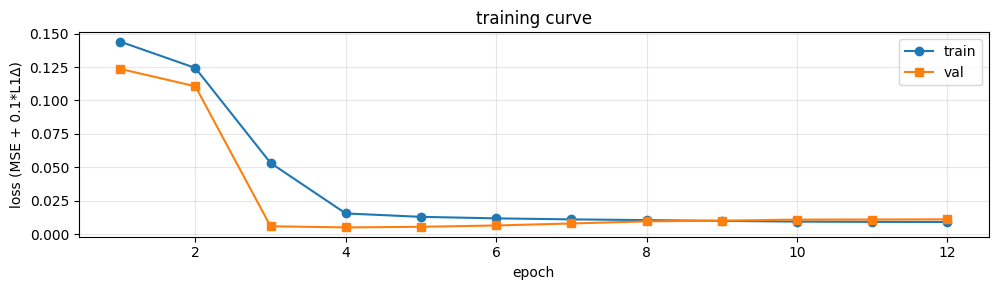

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train", marker="o")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="val",   marker="s")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (MSE + 0.1*L1Δ)")
ax.set_title("training curve")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Score eval set

For every eval window we compute the reconstruction MSE per sensor and
reduce over sensors with `max` (so a single-sensor fault like
`sensor_stuck` is not averaged away). Then we project per-window scores
onto per-row scores by taking, for each row, the **max** score over all
windows that contain it (overlapping windows naturally smooth, max keeps
detection responsive).

In [10]:
@torch.no_grad()
def score_windows(model: nn.Module, X: np.ndarray, batch: int = 1024) -> np.ndarray:
    model.eval()
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i+batch]).to(DEVICE, non_blocking=True)
        x_hat = model(xb)
        err = (x_hat - xb) ** 2                # (B, W, F)
        per_sensor = err.mean(dim=1)           # (B, F)  — mean over time
        s = per_sensor.max(dim=1).values       # (B,)    — worst sensor wins
        out[i:i+batch] = s.detach().cpu().numpy()
    return out


t0 = time.time()
win_scores = score_windows(model, X_eval, batch=2048)
dt = time.time() - t0
print(f"scored {len(win_scores):,} windows in {dt:.1f}s "
      f"({len(win_scores)/max(dt,1e-6):,.0f} win/s)")

scored 672,366 windows in 13.6s (49,562 win/s)


In [11]:
def windows_to_rowscore(prov: pd.DataFrame, scores: np.ndarray,
                        eval_on: pd.DataFrame) -> np.ndarray:
    """Map per-window scores back to per-row by taking max over covering windows."""
    row_score = np.full(len(eval_on), -np.inf, dtype=np.float32)
    # Process per machine; we know windows are contiguous within each machine.
    for m_id, sub in prov.groupby("machineId", sort=False):
        idx = sub.index.to_numpy()
        starts = sub["row_start"].to_numpy()
        ends   = sub["row_end"].to_numpy()
        s_arr  = scores[idx]
        for k in range(len(idx)):
            s, e = starts[k], ends[k] + 1
            cur = row_score[s:e]
            new = s_arr[k]
            np.maximum(cur, new, out=cur)
    return row_score


t0 = time.time()
row_score = windows_to_rowscore(prov_eval, win_scores, eval_on)
print(f"reduced to row scores in {time.time()-t0:.1f}s")
eval_on = eval_on.assign(score=row_score)
eval_on.head()

reduced to row scores in 1.2s


,ts,machineId,state,load,temperature_motor,temperature_bearing,vibration_axial,vibration_radial,current,spindle_rpm,pressure_hydraulic,power,fault_type,is_anomaly,score
0,2026-05-16 08:03:59+00:00,M-101,STARTUP,0.018127,21.543736,21.761002,0.106505,0.143078,1.123478,2989.877441,81.999092,0.252469,normal,False,0.00218
1,2026-05-16 08:04:00+00:00,M-101,STARTUP,0.032968,21.777565,22.471966,0.091531,0.142114,1.663533,2984.347656,81.523140,0.773606,normal,False,0.00218
2,2026-05-16 08:04:01+00:00,M-101,STARTUP,0.045119,22.232618,22.614231,0.131729,0.152751,1.371200,2969.694092,82.433807,0.519999,normal,False,0.00218
3,2026-05-16 08:04:02+00:00,M-101,STARTUP,0.055067,21.754972,21.398512,0.091396,0.165937,1.897591,3013.865723,84.131310,1.132069,normal,False,0.00218
4,2026-05-16 08:04:03+00:00,M-101,STARTUP,0.063212,22.398258,22.448954,0.112186,0.152257,2.410756,3008.250000,84.744919,1.024792,normal,False,0.00218


## 7. Metrics

- **Threshold**: 99.5° percentile of the *training* row-score
  distribution (computed on the held-out validation windows to avoid
  optimism).
- **PR-AUC** per fault family and global, on per-row labels.
- **Detection delay**: for each labelled episode, seconds between
  `onset_ts` and the first row with `score > threshold`.
- **False positive rate** on healthy controls M-101/M-102.

In [12]:
val_scores = score_windows(model, X_train[va_idx], batch=2048)
THRESHOLD = float(np.quantile(val_scores, 0.995))
print(f"threshold (99.5 pct on training-val window scores): {THRESHOLD:.5f}")

threshold (99.5 pct on training-val window scores): 0.01117


In [13]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return float("nan")
    p, r, _ = precision_recall_curve(y_true, y_score)
    return float(auc(r, p))


y_true_all  = eval_on["is_anomaly"].to_numpy().astype(bool)
y_score_all = eval_on["score"].to_numpy()

# Drop rows where the score never got assigned (rare; happens only when a
# machine has fewer than WINDOW ON samples, which never occurs in our data).
valid = np.isfinite(y_score_all)
y_true  = y_true_all[valid]
y_score = y_score_all[valid]
eval_valid = eval_on.loc[valid].copy()

global_pr_auc = pr_auc(y_true, y_score)
print(f"global PR-AUC : {global_pr_auc:.4f}")
print()

# Per-fault-family PR-AUC: positives = rows of this family; negatives = normal rows.
fam_rows = []
for fam in ["bearing", "hydraulic_leak", "sensor_stuck"]:
    is_fam = (eval_valid["fault_type"] == fam).to_numpy()
    is_normal = (eval_valid["fault_type"] == "normal").to_numpy()
    keep = is_fam | is_normal
    auc_fam = pr_auc(is_fam[keep].astype(bool), y_score[keep])
    fam_rows.append({"family": fam, "pr_auc": auc_fam,
                     "positive_rows": int(is_fam.sum()),
                     "negative_rows": int(is_normal.sum())})
fam_df = pd.DataFrame(fam_rows)
fam_df

global PR-AUC : 0.5564



,family,pr_auc,positive_rows,negative_rows
0,bearing,0.309217,64005,493364
1,hydraulic_leak,0.365516,58059,493364
2,sensor_stuck,0.464927,57442,493364


In [14]:
flagged = eval_valid.assign(flag=(y_score > THRESHOLD))

def episode_delay(row):
    m_id = row["machineId"]
    t0 = row["onset_ts"]
    t1 = row["end_ts"]
    sub = flagged[(flagged["machineId"] == m_id)
                  & (flagged["ts"] >= t0)
                  & (flagged["ts"] <  t1)
                  & (flagged["flag"])]
    if len(sub) == 0:
        return float("nan")  # missed
    return (sub["ts"].iloc[0] - t0).total_seconds()


labels_df["detection_delay_s"] = labels_df.apply(episode_delay, axis=1)
print("Detection delay by fault family (seconds; NaN = missed episode):")
delay_summary = labels_df.groupby("fault_type")["detection_delay_s"].agg(
    n="count",
    detected=lambda s: int(s.notna().sum()),
    median_delay_s="median",
    p90_delay_s=lambda s: float(np.nanpercentile(s, 90)) if s.notna().any() else float("nan"),
)
print(delay_summary.to_string())
labels_df[["machineId", "fault_type", "severity_max", "pattern", "duration_s", "detection_delay_s"]]

Detection delay by fault family (seconds; NaN = missed episode):
                n  detected  median_delay_s  p90_delay_s
fault_type                                              
bearing         8         8           741.0       2814.0
hydraulic_leak  9         9          1079.0       2261.8
sensor_stuck    7         7           847.0       1853.2


,machineId,fault_type,severity_max,pattern,duration_s,detection_delay_s
0,M-103,bearing,0.30,ramp,5400.0,309.0
1,M-103,bearing,0.55,ramp,7200.0,350.0
2,M-103,bearing,0.80,ramp,9000.0,4963.0
3,M-103,bearing,1.00,ramp,10800.0,944.0
4,M-104,hydraulic_leak,0.40,ramp,7200.0,3577.0
5,M-104,hydraulic_leak,0.70,oscillation,3600.0,941.0
6,M-104,hydraulic_leak,0.85,ramp,9000.0,1583.0
7,M-104,hydraulic_leak,1.00,oscillation,7200.0,721.0
8,M-105,sensor_stuck,1.00,ramp,1800.0,NaN
9,M-105,sensor_stuck,1.00,ramp,5400.0,1906.0


In [15]:
healthy = eval_valid[eval_valid["machineId"].isin(["M-101", "M-102"])]
healthy_flag = (healthy["score"].to_numpy() > THRESHOLD)
fpr = float(healthy_flag.mean())
print(f"healthy-machine FP rate (M-101 union M-102, ON rows): {100*fpr:.3f}%  "
      f"({int(healthy_flag.sum()):,} / {len(healthy):,})")

healthy-machine FP rate (M-101 union M-102, ON rows): 2.861%  (4,796 / 167,628)


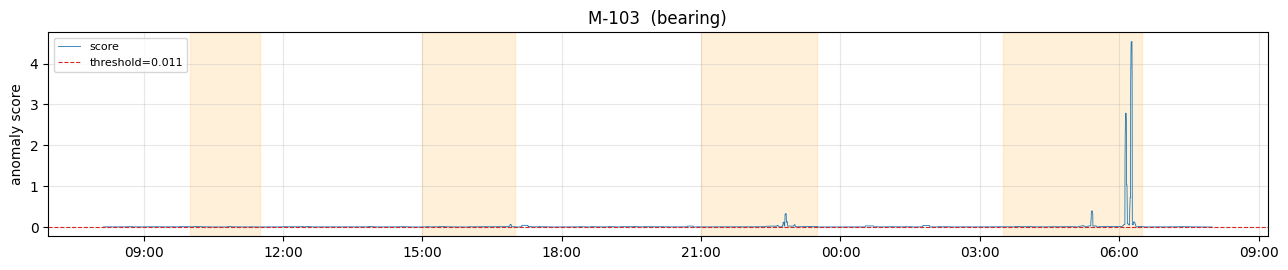

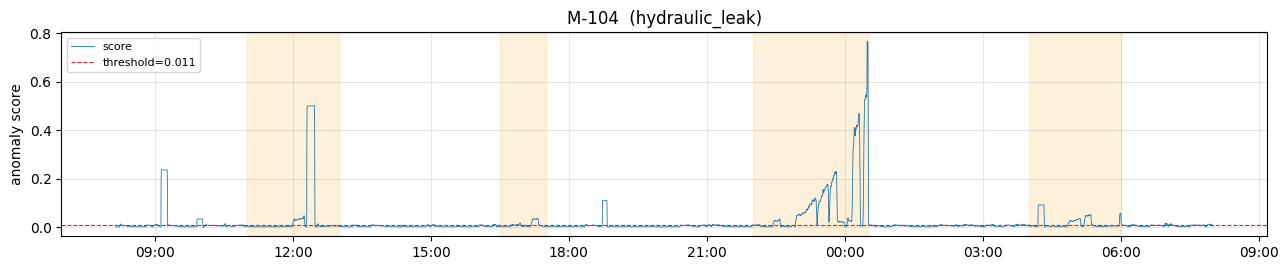

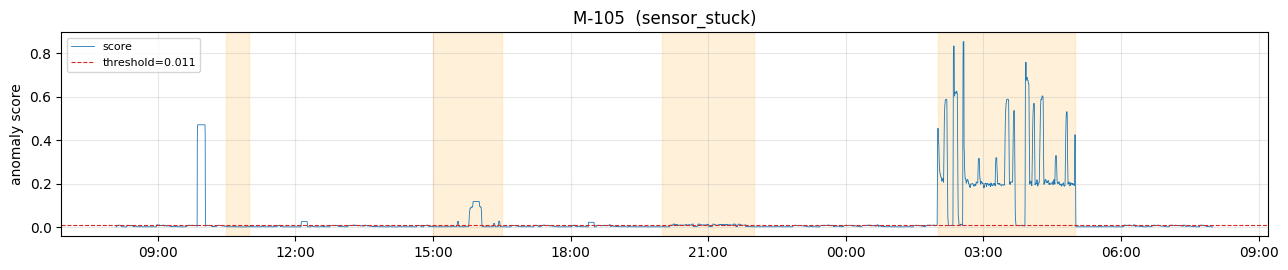

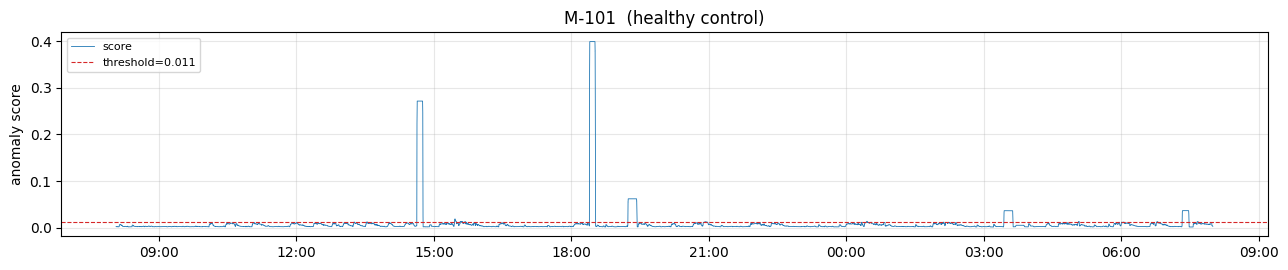

In [16]:
import matplotlib.dates as mdates

def plot_machine(m_id: str, fault: str):
    sub = eval_valid[eval_valid["machineId"] == m_id]
    fig, ax = plt.subplots(figsize=(13, 2.8))
    ax.plot(sub["ts"], sub["score"], lw=0.6, color="tab:blue", label="score")
    ax.axhline(THRESHOLD, color="tab:red", ls="--", lw=0.8, label=f"threshold={THRESHOLD:.3f}")
    eps = labels_df[labels_df["machineId"] == m_id]
    for _, e in eps.iterrows():
        ax.axvspan(e["onset_ts"], e["end_ts"], color="orange", alpha=0.15)
    ax.set_title(f"{m_id}  ({fault})"); ax.set_ylabel("anomaly score")
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout(); plt.show()


plot_machine("M-103", "bearing")
plot_machine("M-104", "hydraulic_leak")
plot_machine("M-105", "sensor_stuck")
plot_machine("M-101", "healthy control")

## 8. ONNX export

We wrap the model so the ONNX graph exposes the **anomaly score**
directly: input `(B, W, F) float32` → output `(B,) float32` (per-window
score, same reduction as `score_windows`).

This is exactly the contract a KQL `python(...)` scorer expects. We also
persist:

- `model.onnx` — the scorer
- `scaler.json` — per-sensor mean/std (in `SENSORS` order)
- `metadata.json` — threshold, window/stride, sensor order, training info

In [17]:
class ScoreWrapper(nn.Module):
    def __init__(self, ae: nn.Module):
        super().__init__()
        self.ae = ae

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, W, F) — already normalized
        x_hat = self.ae(x)
        err = (x_hat - x) ** 2
        per_sensor = err.mean(dim=1)
        return per_sensor.max(dim=1).values


# Export on CPU so the artifact has no CUDA-specific kernels embedded.
export_model = ScoreWrapper(model).to("cpu").eval()

ONNX_PATH = ART_DIR / "model.onnx"
dummy = torch.randn(1, WINDOW, N_FEATURES, dtype=torch.float32)

torch.onnx.export(
    export_model, dummy, ONNX_PATH.as_posix(),
    input_names=["window"], output_names=["score"],
    dynamic_axes={"window": {0: "batch"}, "score": {0: "batch"}},
    opset_version=17, do_constant_folding=True, dynamo=False,
)
print(f"exported: {ONNX_PATH.relative_to(REPO_ROOT)}  "
      f"({ONNX_PATH.stat().st_size/1024:.1f} KB)")

C:\Users\faust\AppData\Local\Temp\ipykernel_30328\1411346633.py:20: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


exported: models\transformer_ae\model.onnx  (881.9 KB)


In [18]:
import onnx, onnxruntime as ort

onnx_model = onnx.load(ONNX_PATH.as_posix())
onnx.checker.check_model(onnx_model)
print(f"onnx ir_version={onnx_model.ir_version}  opset={onnx_model.opset_import[0].version}")

# Parity check: same scores on a handful of eval windows.
sess = ort.InferenceSession(ONNX_PATH.as_posix(), providers=["CPUExecutionProvider"])
sample = X_eval[:128].astype(np.float32)
ort_scores = sess.run(["score"], {"window": sample})[0]

with torch.no_grad():
    torch_scores = export_model(torch.from_numpy(sample)).numpy()

max_abs_diff = float(np.max(np.abs(ort_scores - torch_scores)))
print(f"ONNX vs PyTorch max |diff| on 128 windows: {max_abs_diff:.2e}")
assert max_abs_diff < 1e-3, "ONNX export drifted from PyTorch model"
print("parity OK")

onnx ir_version=8  opset=17


ONNX vs PyTorch max |diff| on 128 windows: 8.15e-09
parity OK


In [19]:
SCALER_PATH = ART_DIR / "scaler.json"
META_PATH   = ART_DIR / "metadata.json"

scaler_payload = {
    "sensors": SENSORS,
    "mean":    [float(x) for x in mean.values],
    "std":     [float(x) for x in std.values],
}
SCALER_PATH.write_text(json.dumps(scaler_payload, indent=2))

meta_payload = {
    "model":            "transformer_ae",
    "window":           WINDOW,
    "stride_train":     STRIDE_TRAIN,
    "stride_eval":      STRIDE_EVAL,
    "n_features":       N_FEATURES,
    "d_model":          D_MODEL,
    "n_heads":          N_HEADS,
    "n_enc_layers":     N_ENC,
    "n_dec_layers":     N_DEC,
    "ff_dim":           FF_DIM,
    "n_parameters":     n_params,
    "threshold":        THRESHOLD,
    "threshold_rule":   "p99.5 on training-val window scores",
    "training": {
        "epochs":       EPOCHS,
        "batch":        BATCH,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "best_val_loss": best_val,
        "device":       str(DEVICE),
    },
    "metrics": {
        "global_pr_auc": global_pr_auc,
        "per_family":    fam_df.set_index("family")["pr_auc"].to_dict(),
        "healthy_fp_rate": fpr,
        "detection_delay_summary":
            delay_summary.reset_index().to_dict(orient="records"),
    },
}
META_PATH.write_text(json.dumps(meta_payload, indent=2, default=str))

torch.save(model.state_dict(), ART_DIR / "model.pt")

print("Artifacts written:")
for p in sorted(ART_DIR.iterdir()):
    print(f"  {p.relative_to(REPO_ROOT)}   {p.stat().st_size/1024:>8.1f} KB")

Artifacts written:
  models\transformer_ae\metadata.json        1.3 KB
  models\transformer_ae\model.onnx      881.9 KB
  models\transformer_ae\model.onnx.data      698.5 KB
  models\transformer_ae\model.pt      725.0 KB
  models\transformer_ae\scaler.json        0.6 KB


## 9. Summary

| | |
|---|---|
| Model | Transformer encoder-decoder AE |
| Parameters | see cell above |
| Threshold rule | 99.5° percentile on training-val window scores |
| Artifacts | `models/transformer_ae/` (model.onnx, scaler.json, metadata.json, model.pt) |

Next steps:

1. If PR-AUC is high on `bearing` but weak on `hydraulic_leak.ramp`
   (subtle, monotonic, sub-sensor) try increasing `WINDOW` to 128 so
   the slow drift fits inside one window.
2. If FP rate on healthy controls is non-trivial switch to a
   per-regime threshold (cluster on encoder latents, then a separate
   `p99.5` per cluster).
3. To wire into Fabric KQL: upload `model.onnx` to the `models` table
   following the pattern in `notebooks/03_train_multivariate_ae.ipynb`,
   using the same `(B, W, F) -> (B,)` contract.